# Weyl reverse geometry with the third coefficient $A_2$

This notebook validates computed Dirichlet eigenvalues on the triaxial ellipsoid
$\Omega(1,1.5,2.3)$ by fitting the three-term Weyl law $N(\lambda)=A_0\lambda^{3/2}+A_1\lambda+A_2\lambda^{1/2}+o(\lambda^{1/2})$. The induced geometric estimates are $V=6\pi^2A_0$ and $S=-16\pi A_1$ and $C=6\pi^2A_2$, where $C=\int_{\partial\Omega}\bar H\,dS$ is the integrated mean curvature with $\bar H=(\kappa_1+\kappa_2)/2$. The key point is the factor 6, not 12, in $C=6\pi^2A_2$.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hearing_ellipsoid_bench.io.eigenvalues import load_eigenvalues_txt
from hearing_ellipsoid_bench.geometry.ellipsoid import (
    true_ellipsoid_volume,
    ellipsoid_surface_area,
    ellipsoid_integrated_mean_curvature,
)

In [2]:
PROJECT_ROOT = Path.home() / "hearing-ellipsoid-bench"
DATA_ROOT = Path.home() / "data"
REFERENCE_DIR = DATA_ROOT / "reference"
GENERATED_DIR = DATA_ROOT / "generated"
OUTPUTS_DIR = DATA_ROOT / "outputs"
ARNOLDI_DIR = OUTPUTS_DIR / "arnoldi_reference_triaxial"
SSG_DIR = OUTPUTS_DIR / "ssg_reference_triaxial"
MFS_DIR = OUTPUTS_DIR / "boundary_mfs_triaxial_windows"

OUT_DIR = OUTPUTS_DIR / "reverse_geometry_a2"
OUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Fixed geometry and reference values

These values are computed from the prescribed semi-axes before any eigenvalue computation enters.

In [3]:
a, b, c = 1.0, 1.5, 2.3

# Which eigenvalue files should be compared?
EIG_FILES = {
    "arnoldi_P2_h0.06_N2000": ARNOLDI_DIR / "ellipsoid_a1_b1.5_c2.3_P2_h0.06_arnoldi_highacc_N2000_eigs.txt",
    "ssg_l22_n19_N2000": SSG_DIR / "ellipsoid_a1_b1.5_c2.3_l34_n19_qr64_qt56_qp112_ssg_N2000_eigs.txt",
    "ssg_l22_n20_N2000": SSG_DIR / "ellipsoid_a1_b1.5_c2.3_l36_n20_qr64_qt56_qp112_ssg_N2000_eigs.txt",
    "boundary_mfs": MFS_DIR / "mfs_cross_scale_stable.txt"
}

# Fit window configuration.
# Each plotted point K uses eigenvalues from FIT_START to K.
FIT_START = 100       # try 1, 50, 100, 200
FIT_END_MAX = 1600  # None = use all available eigenvalues per method

K_VALUES_BASE = np.array([
    50, 100, 150, 200, 300, 400, 500, 600, 700, 800,
    1000, 1200, 1500, 2000, 2500, 3000, 4000, 5000
])

# Plot Configuration
K_MAX_PLOT = None  # None = full range
Y_LIMITS = {
    "V_est_3term": (6, 16), # None = full range
    "S_est_3term": (-50, 50), # None = full range
    "C_est_3term": (-50, 50), # None = full range
    "V_rel_err_3term": (-0.2, 0.2), # None = full range
    "S_rel_err_3term": (-1, 1), # None = full range
    "C_rel_err_3term": (-20, 20) # None = full range
}

In [4]:
V_true = true_ellipsoid_volume(a, b, c)
S_true = ellipsoid_surface_area(a, b, c)
C_true = ellipsoid_integrated_mean_curvature(a, b, c, n_theta=240, n_phi=480)

A0_true = V_true / (6 * np.pi**2)
A1_true = -S_true / (16 * np.pi)
A2_true = C_true / (6 * np.pi**2)

ref = pd.DataFrame([
    {"quantity": "volume", "reference": V_true, "Weyl coefficient": A0_true},
    {"quantity": "surface area", "reference": S_true, "Weyl coefficient": A1_true},
    {"quantity": "integrated mean curvature", "reference": C_true, "Weyl coefficient": A2_true},
])

ref

,quantity,reference,Weyl coefficient
0,volume,14.451326,0.244038
1,surface area,31.355382,-0.623796
2,integrated mean curvature,20.769300,0.350728


# Loading / Plotting Part

## 2. Load eigenvalues

In [5]:
eigs_by_method = {}

for name, path in EIG_FILES.items():
    path = Path(path)

    if not path.exists():
        print(f"missing: {name} -> {path}")
        continue

    eigs = load_eigenvalues_txt(path)
    eigs = np.asarray(eigs, dtype=float)
    eigs = eigs[np.isfinite(eigs)]
    eigs = eigs[eigs > 0]
    eigs = np.sort(eigs)

    eigs_by_method[name] = eigs

    print(f"{name:28s}: {len(eigs):6d} eigenvalues from {path}")

if not eigs_by_method:
    raise FileNotFoundError("No eigenvalue files found. Check EIG_FILES.")

arnoldi_P2_h0.06_N2000      :   2000 eigenvalues from /home/esul01/data/outputs/arnoldi_reference_triaxial/ellipsoid_a1_b1.5_c2.3_P2_h0.06_arnoldi_highacc_N2000_eigs.txt
ssg_l22_n19_N2000           :   2000 eigenvalues from /home/esul01/data/outputs/ssg_reference_triaxial/ellipsoid_a1_b1.5_c2.3_l34_n19_qr64_qt56_qp112_ssg_N2000_eigs.txt
ssg_l22_n20_N2000           :   2000 eigenvalues from /home/esul01/data/outputs/ssg_reference_triaxial/ellipsoid_a1_b1.5_c2.3_l36_n20_qr64_qt56_qp112_ssg_N2000_eigs.txt
boundary_mfs                :   1016 eigenvalues from /home/esul01/data/outputs/boundary_mfs_triaxial_windows/mfs_cross_scale_stable.txt


## 3. Fit the three-term Weyl law along increasing cutoffs

In [6]:
def fit_weyl_3term_window(eigs, fit_start=1, fit_end=None):
    """
    Fit N(lambda) = A0 lambda^(3/2) + A1 lambda + A2 lambda^(1/2)
    on the eigenvalue index window [fit_start, fit_end].

    fit_start and fit_end are 1-based eigenvalue indices.
    """
    eigs = np.asarray(eigs, dtype=float)
    eigs = eigs[np.isfinite(eigs)]
    eigs = eigs[eigs > 0]
    eigs = np.sort(eigs)

    n_total = len(eigs)

    if fit_end is None:
        fit_end = n_total

    fit_start = int(fit_start)
    fit_end = int(fit_end)

    if fit_start < 1:
        raise ValueError("fit_start must be >= 1.")

    if fit_end > n_total:
        raise ValueError(f"fit_end={fit_end} exceeds available eigenvalues {n_total}.")

    if fit_end - fit_start + 1 < 3:
        raise ValueError("Need at least 3 eigenvalues for a 3-term fit.")

    # 1-based indices: lambda_{fit_start}, ..., lambda_{fit_end}
    lam = eigs[fit_start - 1:fit_end]

    # Crucial: use the true counting-function indices, not 1..window_length.
    counts = np.arange(fit_start, fit_end + 1, dtype=float)

    X = np.column_stack([
        lam ** 1.5,
        lam,
        lam ** 0.5,
    ])

    # Mild column scaling improves numerical conditioning.
    scale = np.linalg.norm(X, axis=0)
    scale[scale == 0] = 1.0

    coef_scaled, *_ = np.linalg.lstsq(X / scale, counts, rcond=None)
    A0, A1, A2 = coef_scaled / scale

    return float(A0), float(A1), float(A2)


def reverse_geometry_window_table(
    eigs_by_method,
    *,
    a,
    b,
    c,
    k_values,
    fit_start=1,
    n_theta=240,
    n_phi=480,
):
    V_ref = true_ellipsoid_volume(a, b, c)
    S_ref = ellipsoid_surface_area(a, b, c)
    C_ref = ellipsoid_integrated_mean_curvature(a, b, c, n_theta=n_theta, n_phi=n_phi)

    rows = []

    for method, eigs in eigs_by_method.items():
        eigs = np.asarray(eigs, dtype=float)
        eigs = eigs[np.isfinite(eigs)]
        eigs = eigs[eigs > 0]
        eigs = np.sort(eigs)

        for K in k_values:
            K = int(K)

            if K > len(eigs):
                continue

            if K < fit_start + 2:
                continue

            A0, A1, A2 = fit_weyl_3term_window(
                eigs,
                fit_start=fit_start,
                fit_end=K,
            )

            V_est = 6 * np.pi**2 * A0
            S_est = -16 * np.pi * A1
            C_est = 6 * np.pi**2 * A2

            rows.append({
                "method": method,
                "fit_start": fit_start,
                "K": K,
                "A0_3term": A0,
                "A1_3term": A1,
                "A2_3term": A2,
                "V_est_3term": V_est,
                "S_est_3term": S_est,
                "C_est_3term": C_est,
                "V_true": V_ref,
                "S_true": S_ref,
                "C_true": C_ref,
                "V_rel_err_3term": (V_est - V_ref) / V_ref,
                "S_rel_err_3term": (S_est - S_ref) / S_ref,
                "C_rel_err_3term": (C_est - C_ref) / C_ref,
            })

    return pd.DataFrame(rows)

## 4. Create Table

In [7]:
max_available = max(len(v) for v in eigs_by_method.values())

log_grid = np.unique(
    np.logspace(np.log10(max(50, FIT_START + 2)), np.log10(max_available), 28).astype(int)
)

base = np.unique(np.r_[K_VALUES_BASE, log_grid])

if FIT_END_MAX is not None:
    base = base[base <= FIT_END_MAX]

k_values = [int(K) for K in base if K >= FIT_START + 2 and K <= max_available]

print("FIT_START:", FIT_START)
print("k_values:", k_values)

rg = reverse_geometry_window_table(
    eigs_by_method,
    a=a,
    b=b,
    c=c,
    k_values=k_values,
    fit_start=FIT_START,
    n_theta=240,
    n_phi=480,
)

rg.tail()

FIT_START: 100
k_values: [113, 127, 141, 150, 158, 176, 197, 200, 220, 246, 275, 300, 307, 342, 382, 400, 427, 477, 500, 532, 594, 600, 664, 700, 741, 800, 828, 924, 1000, 1032, 1152, 1200, 1286, 1436, 1500]


,method,fit_start,K,A0_3term,A1_3term,A2_3term,V_est_3term,S_est_3term,C_est_3term,V_true,S_true,C_true,V_rel_err_3term,S_rel_err_3term,C_rel_err_3term
129,boundary_mfs,100,741,0.142308,1.232640,-8.208917,8.427113,-61.959233,-486.112599,14.451326,31.355382,20.7693,-0.416862,-2.976032,-24.405344
130,boundary_mfs,100,800,0.081286,2.704176,-16.852518,4.813580,-135.926714,-997.966140,14.451326,31.355382,20.7693,-0.666911,-5.335036,-49.050062
131,boundary_mfs,100,828,0.045174,3.589640,-22.133602,2.675113,-180.434964,-1310.699396,14.451326,31.355382,20.7693,-0.814888,-6.754513,-64.107540
132,boundary_mfs,100,924,-0.097026,7.173468,-44.061083,-5.745621,-360.577836,-2609.192767,14.451326,31.355382,20.7693,-1.397584,-12.499711,-126.627384
133,boundary_mfs,100,1000,-0.301626,12.612648,-79.047793,-17.861554,-633.980857,-4681.022667,14.451326,31.355382,20.7693,-2.235980,-21.219204,-226.381827


## Plot

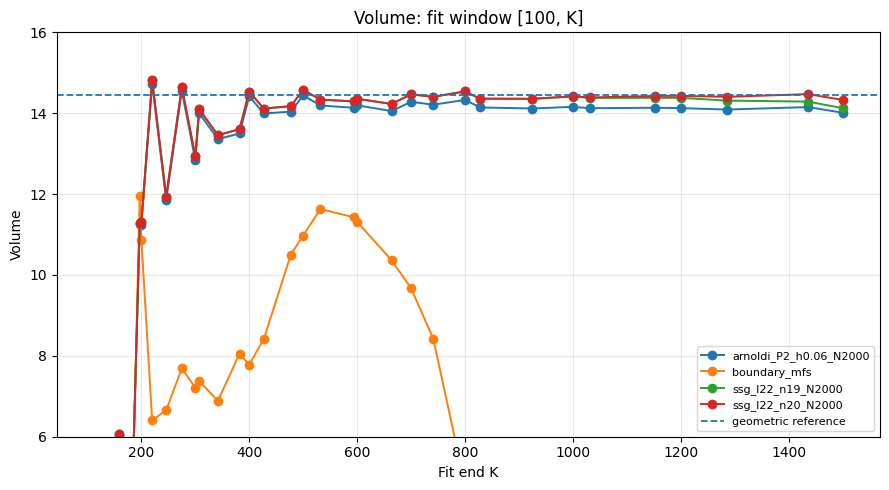

saved: /home/esul01/data/outputs/reverse_geometry_a2/reverse_volume_reference_line.png
saved: /home/esul01/data/outputs/reverse_geometry_a2/reverse_volume_reference_line.pdf


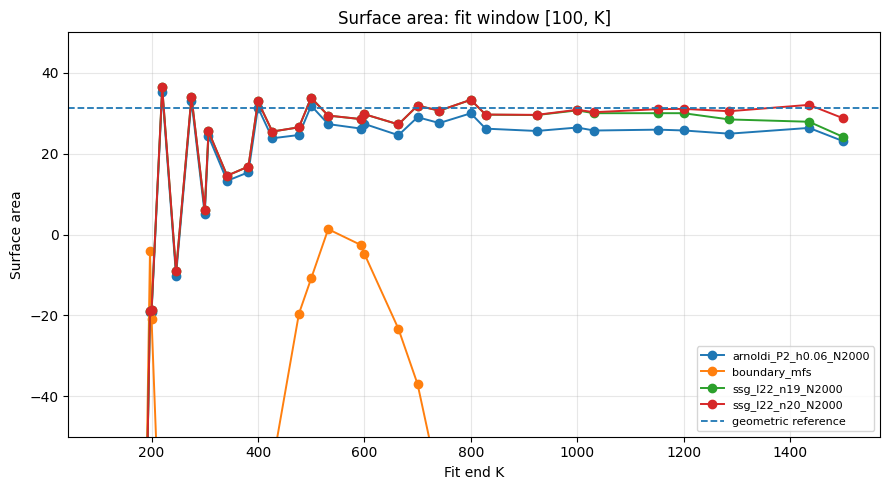

saved: /home/esul01/data/outputs/reverse_geometry_a2/reverse_surface_reference_line.png
saved: /home/esul01/data/outputs/reverse_geometry_a2/reverse_surface_reference_line.pdf


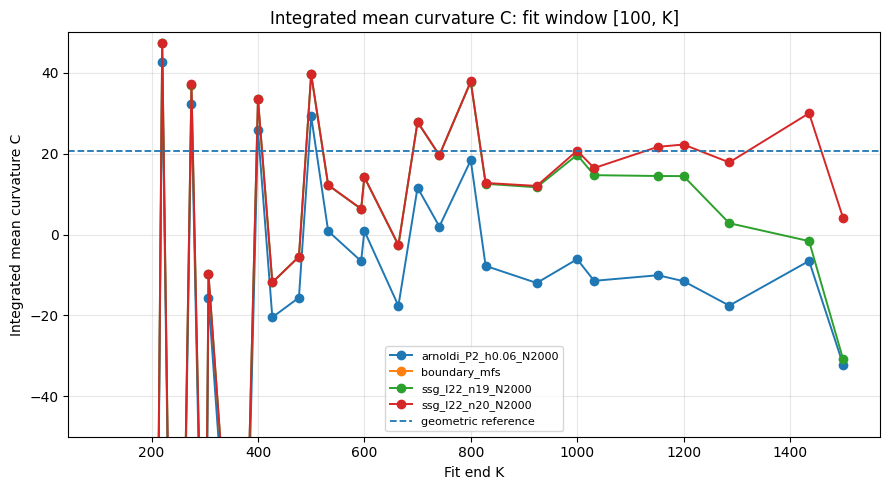

saved: /home/esul01/data/outputs/reverse_geometry_a2/reverse_curvature_reference_line.png
saved: /home/esul01/data/outputs/reverse_geometry_a2/reverse_curvature_reference_line.pdf


In [8]:
df_plot = rg.copy()

if K_MAX_PLOT is not None:
    df_plot = df_plot[df_plot["K"] <= K_MAX_PLOT].copy()

plot_specs = [
    ("V_est_3term", "V_true", "Volume", "reverse_volume_reference_line.png"),
    ("S_est_3term", "S_true", "Surface area", "reverse_surface_reference_line.png"),
    ("C_est_3term", "C_true", "Integrated mean curvature C", "reverse_curvature_reference_line.png"),
]

for estimate_col, ref_col, ylabel, filename in plot_specs:
    fig, ax = plt.subplots(figsize=(9, 5))

    for method, part in df_plot.groupby("method"):
        part = part.sort_values("K")
        ax.plot(
            part["K"],
            part[estimate_col],
            marker="o",
            linewidth=1.4,
            label=method,
        )

    ref_value = float(df_plot[ref_col].dropna().iloc[0])
    ax.axhline(
        ref_value,
        linestyle="--",
        linewidth=1.3,
        label="geometric reference",
    )

    ax.set_xlabel("Fit end K")
    ax.set_ylabel(ylabel)

    ylim = Y_LIMITS.get(estimate_col)
    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.set_title(f"{ylabel}: fit window [{FIT_START}, K]")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    fig.tight_layout()

    png_path = OUT_DIR / filename
    pdf_path = OUT_DIR / Path(filename).with_suffix(".pdf").name

    fig.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight",
    )
    fig.savefig(
        pdf_path,
        bbox_inches="tight",
    )

    plt.show()

    print("saved:", png_path)
    print("saved:", pdf_path)

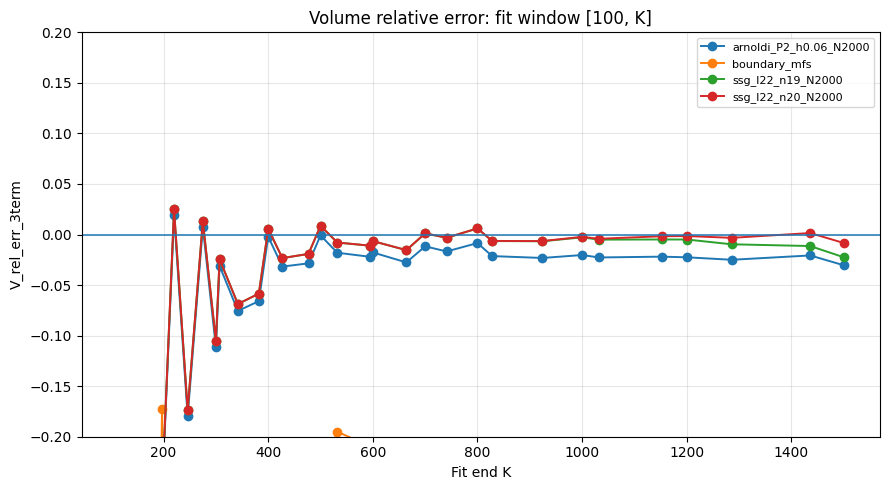

saved: /home/esul01/data/outputs/reverse_geometry_a2/V_rel_err_3term_fitstart_100.png
saved: /home/esul01/data/outputs/reverse_geometry_a2/V_rel_err_3term_fitstart_100.pdf


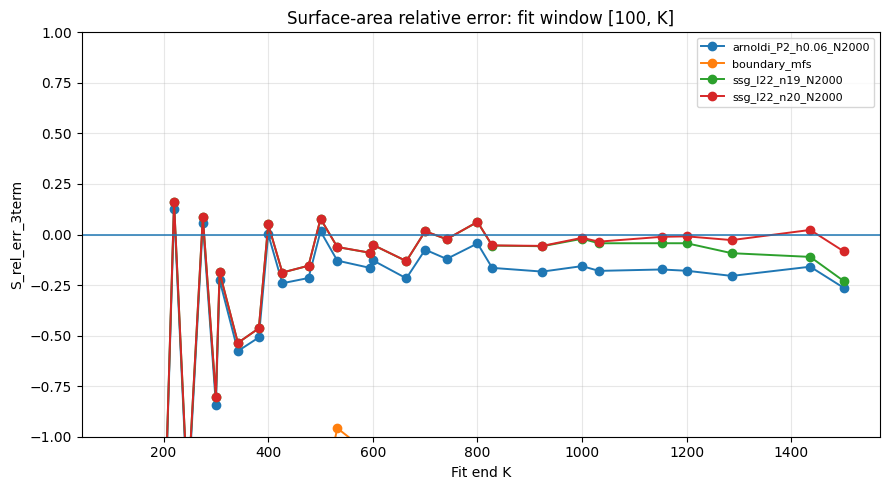

saved: /home/esul01/data/outputs/reverse_geometry_a2/S_rel_err_3term_fitstart_100.png
saved: /home/esul01/data/outputs/reverse_geometry_a2/S_rel_err_3term_fitstart_100.pdf


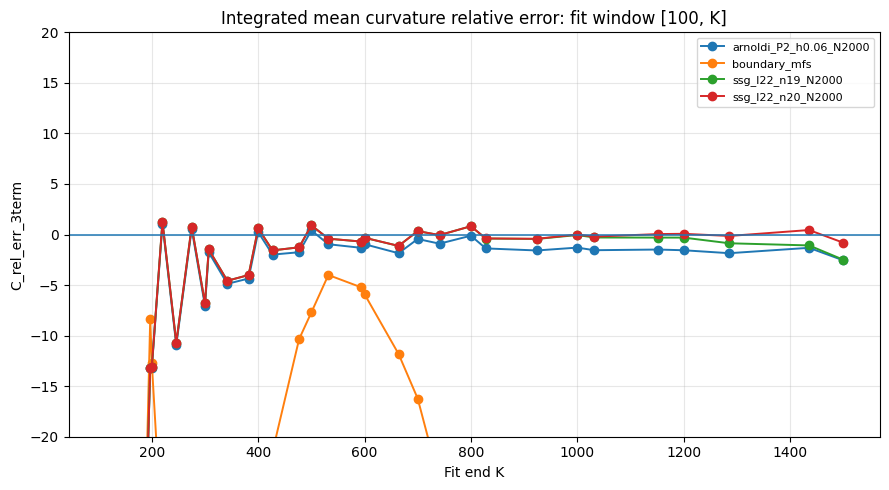

saved: /home/esul01/data/outputs/reverse_geometry_a2/C_rel_err_3term_fitstart_100.png
saved: /home/esul01/data/outputs/reverse_geometry_a2/C_rel_err_3term_fitstart_100.pdf


In [9]:
error_specs = [
    ("V_rel_err_3term", "Volume relative error"),
    ("S_rel_err_3term", "Surface-area relative error"),
    ("C_rel_err_3term", "Integrated mean curvature relative error"),
]

for err_col, title in error_specs:
    fig, ax = plt.subplots(figsize=(9, 5))

    for method, part in df_plot.groupby("method"):
        part = part.sort_values("K")
        ax.plot(part["K"], part[err_col], marker="o", linewidth=1.4, label=method)

    ax.axhline(0.0, linewidth=1.1)
    ax.set_xlabel("Fit end K")
    ax.set_ylabel(err_col)

    ylim = Y_LIMITS.get(err_col)
    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.set_title(f"{title}: fit window [{FIT_START}, K]")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    fig.tight_layout()

    png_path = OUT_DIR / f"{err_col}_fitstart_{FIT_START}.png"
    pdf_path = OUT_DIR / f"{err_col}_fitstart_{FIT_START}.pdf"

    fig.savefig(png_path, dpi=200, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")

    plt.show()

    print("saved:", png_path)
    print("saved:", pdf_path)

In [10]:
suffix = f"fitstart_{FIT_START}"

rg.to_csv(OUT_DIR / f"reverse_geometry_a2_{suffix}.csv", index=False)
ref.to_csv(OUT_DIR / "geometric_reference_values.csv", index=False)

print("saved tables to:", OUT_DIR)

saved tables to: /home/esul01/data/outputs/reverse_geometry_a2


In [11]:
import numpy as np
import pandas as pd
import json

MFS_PATH = "/home/esul01/data/outputs/boundary_mfs_triaxial/ellipsoid_a1_b1.5_c2.3_k2-22_scan16000_bdry2400_src1800_int900_scale1.3_boundary_mfs_eigs.txt"
mfs = np.loadtxt(MFS_PATH)
META_PATH = Path("/home/esul01/data/outputs/boundary_mfs_triaxial/ellipsoid_a1_b1.5_c2.3_k2-22_scan16000_bdry2400_src1800_int900_scale1.3_boundary_mfs_meta.json")
meta_mfs = json.loads(META_PATH.read_text())

fem = np.loadtxt(ARNOLDI_DIR / "ellipsoid_a1_b1.5_c2.3_P2_h0.06_arnoldi_highacc_N2000_eigs.txt")
ssg = np.loadtxt(SSG_DIR / "ellipsoid_a1_b1.5_c2.3_l36_n20_qr64_qt56_qp112_ssg_N2000_eigs.txt")

print("MFS file:", MFS_PATH)
print("Number of candidates:", len(mfs))
print("lambda_min:", mfs[0])
print("lambda_max:", mfs[-1])
print("k_max reached:", np.sqrt(mfs[-1]))
print("runtime_sec:", meta_mfs["runtime_sec"])
print("source_scale:", meta_mfs["source_scale"])
print("boundary/sources/interior:",
      meta_mfs["n_boundary"],
      meta_mfs["n_sources"],
      meta_mfs["n_interior"])

def nearest_reference_indices(values, reference):
    values = np.asarray(values)
    reference = np.asarray(reference)

    pos = np.searchsorted(reference, values)
    pos = np.clip(pos, 1, len(reference) - 1)

    left_idx = pos - 1
    right_idx = pos

    choose_right = (
        np.abs(reference[right_idx] - values)
        <
        np.abs(reference[left_idx] - values)
    )

    idx = np.where(choose_right, right_idx, left_idx)
    nearest = reference[idx]
    rel_err = np.abs(values - nearest) / nearest

    return idx, nearest, rel_err


idx_ssg, nearest_ssg, rel_ssg = nearest_reference_indices(mfs, ssg)

unique_idx = np.unique(idx_ssg)
max_idx = int(unique_idx.max())

missing = np.setdiff1d(
    np.arange(max_idx + 1),
    unique_idx,
)

duplicate_matches = len(idx_ssg) - len(unique_idx)

# Länge des vollständigen Präfixes ab Index 0
contiguous_prefix = 0
for i in range(len(ssg)):
    if i in unique_idx:
        contiguous_prefix += 1
    else:
        break

print("MFS candidates:", len(mfs))
print("Unique matched SSG indices:", len(unique_idx))
print("Largest matched SSG index:", max_idx + 1)
print("Missing SSG indices up to there:", len(missing))
print("Duplicate MFS matches:", duplicate_matches)
print("Complete initial prefix:", contiguous_prefix)

print("\nAccuracy against SSG")
print("median:", np.median(rel_ssg))
print("mean:", np.mean(rel_ssg))
print("max:", np.max(rel_ssg))
print("<= 1e-3:", np.sum(rel_ssg <= 1e-3))
print("<= 1e-4:", np.sum(rel_ssg <= 1e-4))
print("<= 1e-5:", np.sum(rel_ssg <= 1e-5))

mfs_comparison = pd.DataFrame({
    "lambda_mfs": mfs,
    "lambda_ssg": nearest_ssg,
    "ssg_index": idx_ssg + 1,
    "rel_err_ssg": rel_ssg,
})

idx_fem, nearest_fem, rel_fem = nearest_reference_indices(mfs, fem)

mfs_comparison["lambda_fem"] = nearest_fem
mfs_comparison["fem_index"] = idx_fem + 1
mfs_comparison["rel_err_fem"] = rel_fem

mfs_comparison.to_csv(
    MFS_DIR / "monster_mfs_vs_fem_ssg.csv",
    index=False,
)

display(mfs_comparison.head(30))
display(mfs_comparison.tail(30))

mfs_prefix = mfs[:contiguous_prefix]

print("MFS prefix used for reverse geometry:", len(mfs_prefix))
print("last prefix eigenvalue:", mfs_prefix[-1] if len(mfs_prefix) else None)

eigs_by_method["Boundary MFS"] = mfs_prefix

max_available = max(len(v) for v in eigs_by_method.values())

log_grid = np.unique(
    np.logspace(
        np.log10(max(50, FIT_START + 2)),
        np.log10(max_available),
        28,
    ).astype(int)
)

base = np.unique(np.r_[K_VALUES_BASE, log_grid])

if FIT_END_MAX is not None:
    base = base[base <= FIT_END_MAX]

k_values = [
    int(K)
    for K in base
    if FIT_START + 2 <= K <= max_available
]

rg = reverse_geometry_window_table(
    eigs_by_method,
    a=a,
    b=b,
    c=c,
    k_values=k_values,
    fit_start=FIT_START,
    n_theta=240,
    n_phi=480,
)

MFS file: /home/esul01/data/outputs/boundary_mfs_triaxial/ellipsoid_a1_b1.5_c2.3_k2-22_scan16000_bdry2400_src1800_int900_scale1.3_boundary_mfs_eigs.txt
Number of candidates: 816
lambda_min: 5.270972622805766
lambda_max: 441.75530472533
k_max reached: 21.0179757523252
runtime_sec: 33489.65016502398
source_scale: 1.3
boundary/sources/interior: 2400 1800 900
MFS candidates: 816
Unique matched SSG indices: 814
Largest matched SSG index: 1984
Missing SSG indices up to there: 1170
Duplicate MFS matches: 2
Complete initial prefix: 39

Accuracy against SSG
median: 3.213429717951273e-05
mean: 4.971150114007837e-05
max: 0.00044184789869907733
<= 1e-3: 816
<= 1e-4: 697
<= 1e-5: 109


,lambda_mfs,lambda_ssg,ssg_index,rel_err_ssg,lambda_fem,fem_index,rel_err_fem
0,5.270973,5.270983,1,0.000002,5.272850,1,0.000356
1,7.855527,7.855560,2,0.000004,7.858547,2,0.000384
2,10.003927,10.003949,3,0.000002,10.008034,3,0.000410
3,11.161806,11.161899,4,0.000008,11.166431,4,0.000414
4,13.352142,13.352199,5,0.000004,13.357868,5,0.000429
5,14.324788,14.324820,6,0.000002,14.329302,6,0.000315
6,15.223279,15.223484,7,0.000013,15.230044,7,0.000444
7,16.688013,16.688067,8,0.000003,16.695525,8,0.000450
8,17.367155,17.367293,9,0.000008,17.374946,9,0.000448
9,18.172025,18.172119,10,0.000005,18.178039,10,0.000331


,lambda_mfs,lambda_ssg,ssg_index,rel_err_ssg,lambda_fem,fem_index,rel_err_fem
786,320.241303,320.251457,1205,0.000032,320.210358,1201,0.000097
787,321.656062,321.660721,1214,0.000014,321.715397,1209,0.000184
788,322.852281,322.855400,1221,0.000010,322.729148,1215,0.000382
789,325.506759,325.516228,1238,0.000029,325.594425,1229,0.000269
790,329.087665,329.230788,1254,0.000435,329.117423,1249,0.000090
791,329.930573,329.925423,1259,0.000016,329.838231,1255,0.000280
792,333.433402,333.437857,1287,0.000013,333.449720,1277,0.000049
793,333.582085,333.584577,1288,0.000007,333.475082,1278,0.000321
794,335.699576,335.709602,1297,0.000030,335.332991,1295,0.001093
795,336.100832,336.102360,1301,0.000005,336.153469,1296,0.000157


MFS prefix used for reverse geometry: 39
last prefix eigenvalue: 39.590780900505116


In [12]:
from pathlib import Path
import numpy as np
import pandas as pd

MFS_WIN_DIR = Path("/home/esul01/data/outputs/boundary_mfs_triaxial_windows")

mfs_win = np.loadtxt(MFS_WIN_DIR / "mfs_cross_scale_stable.txt")

print("stable MFS candidates:", len(mfs_win))
print("lambda_min:", mfs_win[0])
print("lambda_max:", mfs_win[-1])
print("k_max:", np.sqrt(mfs_win[-1]))

stable MFS candidates: 1016
lambda_min: 5.270972647422523
lambda_max: 483.3759715823514
k_max: 21.985812961597563


In [13]:
idx_ssg, nearest_ssg, rel_ssg = nearest_reference_indices(mfs_win, ssg)

unique_idx = np.unique(idx_ssg)
max_idx = int(unique_idx.max())

missing = np.setdiff1d(
    np.arange(max_idx + 1),
    unique_idx,
)

duplicate_matches = len(idx_ssg) - len(unique_idx)

contiguous_prefix = 0
unique_set = set(unique_idx.tolist())

for i in range(len(ssg)):
    if i in unique_set:
        contiguous_prefix += 1
    else:
        break

print("MFS stable candidates:", len(mfs_win))
print("Unique matched SSG indices:", len(unique_idx))
print("Largest matched SSG index:", max_idx + 1)
print("Missing SSG indices up to there:", len(missing))
print("Duplicate MFS matches:", duplicate_matches)
print("Complete initial prefix:", contiguous_prefix)

print("\nAccuracy against SSG")
print("median:", np.median(rel_ssg))
print("mean:", np.mean(rel_ssg))
print("max:", np.max(rel_ssg))
print("<= 1e-3:", np.sum(rel_ssg <= 1e-3))
print("<= 1e-4:", np.sum(rel_ssg <= 1e-4))
print("<= 1e-5:", np.sum(rel_ssg <= 1e-5))

MFS stable candidates: 1016
Unique matched SSG indices: 998
Largest matched SSG index: 2000
Missing SSG indices up to there: 1002
Duplicate MFS matches: 18
Complete initial prefix: 143

Accuracy against SSG
median: 3.619167822677455e-05
mean: 0.0005131686621531066
max: 0.08929185706910324
<= 1e-3: 1007
<= 1e-4: 834
<= 1e-5: 117


In [14]:
mfs_prefix = mfs_win[:contiguous_prefix]
eigs_by_method["Boundary MFS"] = mfs_prefix

In [15]:
from pathlib import Path
import numpy as np
import pandas as pd

HANKEL_DIR = Path("/home/esul01/data/outputs/hankel_resolvent_triaxial_windows")

hankel = np.loadtxt(HANKEL_DIR / "hankel_dense_stable_eigs.txt")
clusters = pd.read_csv(HANKEL_DIR / "hankel_dense_stable_clusters.csv")

print("stable Hankel candidates:", len(hankel))
print("lambda_min:", hankel[0])
print("lambda_max:", hankel[-1])
display(clusters["n_seeds"].value_counts().sort_index())

stable Hankel candidates: 1052
lambda_min: 5.272850187022286
lambda_max: 448.8997840719852


n_seeds
4    194
5    202
6    181
7    167
8    308
Name: count, dtype: int64

In [16]:
def nearest_reference_indices(values, reference):
    values = np.asarray(values)
    reference = np.asarray(reference)

    idx = np.searchsorted(reference, values)
    idx = np.clip(idx, 1, len(reference) - 1)

    left = idx - 1
    right = idx

    choose_right = np.abs(reference[right] - values) < np.abs(reference[left] - values)
    nearest_idx = np.where(choose_right, right, left)
    nearest = reference[nearest_idx]
    rel_err = np.abs(values - nearest) / np.maximum(np.abs(nearest), 1.0)

    return nearest_idx, nearest, rel_err

In [17]:
idx_ssg, nearest_ssg, rel_ssg = nearest_reference_indices(hankel, ssg)
idx_fem, nearest_fem, rel_fem = nearest_reference_indices(hankel, fem)

unique_idx = np.unique(idx_ssg)
max_idx = int(unique_idx.max())

missing = np.setdiff1d(np.arange(max_idx + 1), unique_idx)

unique_set = set(unique_idx.tolist())
contiguous_prefix = 0
for i in range(len(ssg)):
    if i in unique_set:
        contiguous_prefix += 1
    else:
        break

print("Stable Hankel candidates:", len(hankel))
print("Unique matched SSG indices:", len(unique_idx))
print("Largest matched SSG index:", max_idx + 1)
print("Missing SSG indices up to there:", len(missing))
print("Complete initial prefix:", contiguous_prefix)

print("\nAccuracy vs SSG")
print("median:", np.median(rel_ssg))
print("mean:", np.mean(rel_ssg))
print("max:", np.max(rel_ssg))
print("<= 1e-3:", np.sum(rel_ssg <= 1e-3))
print("<= 1e-4:", np.sum(rel_ssg <= 1e-4))
print("<= 1e-5:", np.sum(rel_ssg <= 1e-5))

print("\nAccuracy vs FEM")
print("median:", np.median(rel_fem))
print("mean:", np.mean(rel_fem))
print("max:", np.max(rel_fem))
print("<= 1e-3:", np.sum(rel_fem <= 1e-3))
print("<= 1e-4:", np.sum(rel_fem <= 1e-4))
print("<= 1e-5:", np.sum(rel_fem <= 1e-5))

Stable Hankel candidates: 1052
Unique matched SSG indices: 933
Largest matched SSG index: 2000
Missing SSG indices up to there: 1067
Complete initial prefix: 39

Accuracy vs SSG
median: 0.00035011806784930746
mean: 0.0004742207862986878
max: 0.011599475722772049
<= 1e-3: 989
<= 1e-4: 209
<= 1e-5: 20

Accuracy vs FEM
median: 0.0001432997991182517
mean: 0.0002910059584785039
max: 0.009734979312768425
<= 1e-3: 1009
<= 1e-4: 467
<= 1e-5: 221


In [18]:
hankel_comparison = pd.DataFrame({
    "lambda_hankel": hankel,
    "lambda_ssg": nearest_ssg,
    "ssg_index": idx_ssg + 1,
    "rel_err_ssg": rel_ssg,
    "lambda_fem": nearest_fem,
    "fem_index": idx_fem + 1,
    "rel_err_fem": rel_fem,
})

hankel_comparison.to_csv(
    HANKEL_DIR / "hankel_dense_vs_fem_ssg.csv",
    index=False,
)

display(hankel_comparison.head(30))
display(hankel_comparison.tail(30))

,lambda_hankel,lambda_ssg,ssg_index,rel_err_ssg,lambda_fem,fem_index,rel_err_fem
0,5.272850,5.270983,1,0.000354,5.272850,1,9.702357e-14
1,7.858547,7.855560,2,0.000380,7.858547,2,1.078217e-13
2,10.008034,10.003949,3,0.000408,10.008034,3,1.553065e-13
3,11.166431,11.161899,4,0.000406,11.166431,4,2.160785e-12
4,13.357868,13.352199,5,0.000425,13.357868,5,1.643658e-12
5,14.329302,14.324820,6,0.000313,14.329302,6,1.272271e-12
6,15.230044,15.223484,7,0.000431,15.230044,7,5.737744e-12
7,16.695525,16.688067,8,0.000447,16.695525,8,2.310947e-13
8,17.374946,17.367293,9,0.000441,17.374946,9,8.342513e-14
9,18.178039,18.172119,10,0.000326,18.178039,10,1.645799e-12


,lambda_hankel,lambda_ssg,ssg_index,rel_err_ssg,lambda_fem,fem_index,rel_err_fem
1022,437.569060,437.570403,1960,0.000003,437.575439,1951,0.000015
1023,437.975139,437.965291,1962,0.000022,438.037789,1953,0.000143
1024,438.436536,438.423923,1965,0.000029,438.294996,1959,0.000323
1025,438.733522,438.654853,1968,0.000179,438.756442,1961,0.000052
1026,439.069525,439.023407,1971,0.000105,439.274214,1964,0.000466
1027,439.453957,439.620628,1973,0.000379,439.301298,1965,0.000348
1028,439.743007,439.620628,1973,0.000278,439.747731,1968,0.000011
1029,440.042808,440.226467,1974,0.000417,440.070428,1970,0.000063
1030,440.501456,440.350570,1975,0.000343,440.545216,1972,0.000099
1031,440.810966,440.928534,1976,0.000267,440.829701,1974,0.000043


In [19]:
FIT_START = 100

hankel_prefix = hankel[:contiguous_prefix]

print("Hankel prefix length:", len(hankel_prefix))
print("last prefix lambda:", hankel_prefix[-1] if len(hankel_prefix) else None)

if len(hankel_prefix) <= FIT_START + 20:
    print("Hankel prefix too short for reverse-geometry fitting.")
else:
    print("Hankel prefix is long enough for exploratory reverse-geometry fitting.")

Hankel prefix length: 39
last prefix lambda: 39.60513495229418
Hankel prefix too short for reverse-geometry fitting.
